# pyResToolbox — Nodal Analysis, VFP Generation & Hydrate Assessment

This notebook demonstrates:

1. **Outflow (VLP) curves** for gas and oil wells (Field & Metric)
2. **VFPPROD table generation** for Eclipse
3. **Nodal operating point** solutions for gas and oil production
4. **Hydrate analysis** of the nodal systems — water balance, inhibitor dosing & injection rates

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyrestoolbox import gas, oil, nodal, simtools
from pyrestoolbox.nodal import WellSegment, Completion, Reservoir
from pyrestoolbox.gas import GasPVT, gas_hydrate
from pyrestoolbox.oil import OilPVT

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

---
## 1. Well & Reservoir Definitions

Define a common well geometry and two reservoirs (gas & oil) that will be reused throughout.

In [2]:
# --- Well Geometry (Field units) ---
seg_tubing = WellSegment(md=8000, id=2.992, deviation=0, roughness=0.0006)
comp_field = Completion(segments=[seg_tubing], tht=100, bht=220)

print('=== Completion (Field) ===')
print(f'  Total MD : {comp_field.total_md:.0f} ft')
print(f'  Total TVD: {comp_field.total_tvd:.0f} ft')
print(f'  WHT / BHT: {comp_field.tht:.0f} / {comp_field.bht:.0f} degF')
print(f'  Tubing ID: {comp_field.tid:.3f} in')
print()
print('Profile:')
print(comp_field.profile())

=== Completion (Field) ===
  Total MD : 8000 ft
  Total TVD: 8000 ft
  WHT / BHT: 100 / 220 degF
  Tubing ID: 2.992 in

Profile:
       MD     TVD  Deviation     ID  Roughness
0     0.0     0.0          0  2.992     0.0006
1  8000.0  8000.0          0  2.992     0.0006


In [3]:
# --- Gas Reservoir (Field) ---
gas_pvt_field = GasPVT(sg=0.70, co2=0.03, h2s=0.01, n2=0.02)
gas_res_field = Reservoir(pr=4500, degf=220, k=50, h=40, re=2000, rw=0.354, S=2)

print('=== Gas Reservoir (Field) ===')
print(f'  Pr     : {gas_res_field.pr:.0f} psia')
print(f'  T_res  : {gas_res_field.degf:.0f} degF')
print(f'  k×h    : {gas_res_field.k * gas_res_field.h:.0f} mD·ft')
print(f'  Skin   : {gas_res_field.S}')
print(f'  Gas SG : {gas_pvt_field.sg}')
print(f'  Tc/Pc  : {gas_pvt_field.tc:.1f} degR / {gas_pvt_field.pc:.1f} psia')

=== Gas Reservoir (Field) ===
  Pr     : 4500 psia
  T_res  : 220 degF
  k×h    : 2000 mD·ft
  Skin   : 2
  Gas SG : 0.7
  Tc/Pc  : 364.9 degR / 675.9 psia


In [4]:
# --- Oil Reservoir (Field) ---
oil_pvt_field = OilPVT(api=35, sg_sp=0.65, pb=3200, degf=220)

oil_res_field = Reservoir(pr=4500, degf=220, k=200, h=30, re=2000, rw=0.354, S=0)

print('=== Oil Reservoir (Field) ===')
print(f'  Pr       : {oil_res_field.pr:.0f} psia')
print(f'  API      : {oil_pvt_field.api}')
print(f'  Pb       : {oil_pvt_field.pb:.0f} psia')
print(f'  Rsb      : {oil_pvt_field.rsb:.1f} scf/stb')
print(f'  vis_frac : {oil_pvt_field.vis_frac}')
print(f'  rsb_frac : {oil_pvt_field.rsb_frac:.4f}')

=== Oil Reservoir (Field) ===
  Pr       : 4500 psia
  API      : 35
  Pb       : 3200 psia
  Rsb      : 517.8 scf/stb
  vis_frac : 1.0
  rsb_frac : 1.0000


---
## 2. Outflow (VLP) Curves — Gas Well

### 2a. Single VLP curve (Field units)

In [5]:
thp_gas = 500  # psia

vlp_gas = nodal.outflow_curve(
    thp=thp_gas, completion=comp_field,
    vlpmethod='WG', well_type='gas',
    n_rates=25, max_rate=30,
    gsg=gas_pvt_field.sg, cgr=5
)

print(f'VLP curve: {len(vlp_gas["rates"])} points')
print(f'Rate range: {vlp_gas["rates"][0]:.2f} – {vlp_gas["rates"][-1]:.2f} MMscf/d')
print(f'BHP range : {min(vlp_gas["bhp"]):.0f} – {max(vlp_gas["bhp"]):.0f} psia')
print()
print('First 5 points:')
for i in range(5):
    print(f'  {vlp_gas["rates"][i]:8.2f} MMscf/d  ->  {vlp_gas["bhp"][i]:8.1f} psia')

VLP curve: 25 points
Rate range: 0.01 – 30.00 MMscf/d
BHP range : 599 – 2598 psia

First 5 points:
      0.01 MMscf/d  ->     598.9 psia
      1.26 MMscf/d  ->     833.0 psia
      2.51 MMscf/d  ->     756.0 psia
      3.76 MMscf/d  ->     762.0 psia
      5.01 MMscf/d  ->     796.2 psia


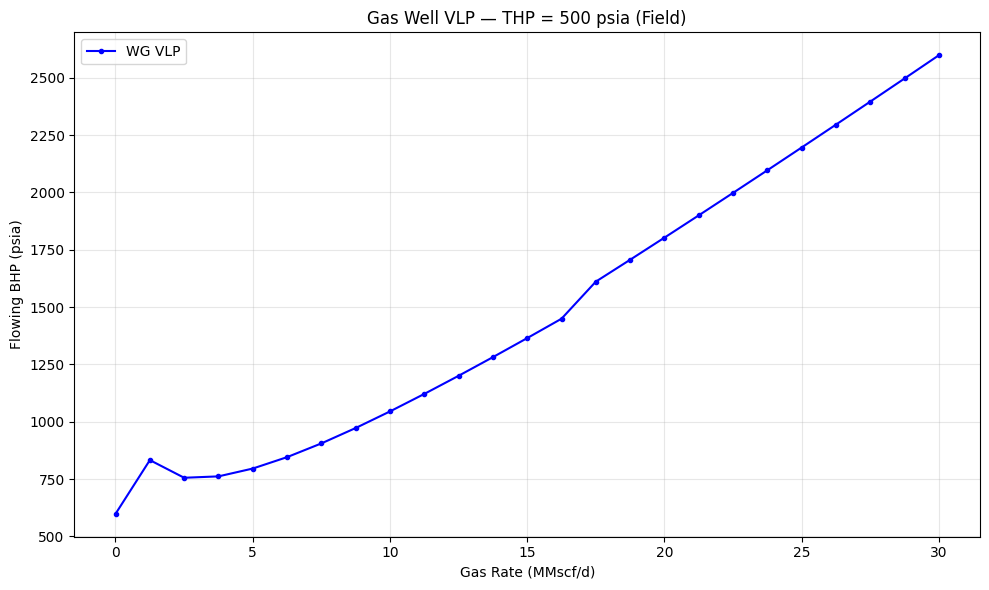

In [6]:
fig, ax = plt.subplots()
ax.plot(vlp_gas['rates'], vlp_gas['bhp'], 'b-o', markersize=3, label='WG VLP')
ax.set_xlabel('Gas Rate (MMscf/d)')
ax.set_ylabel('Flowing BHP (psia)')
ax.set_title(f'Gas Well VLP — THP = {thp_gas} psia (Field)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2b. Compare all four VLP methods

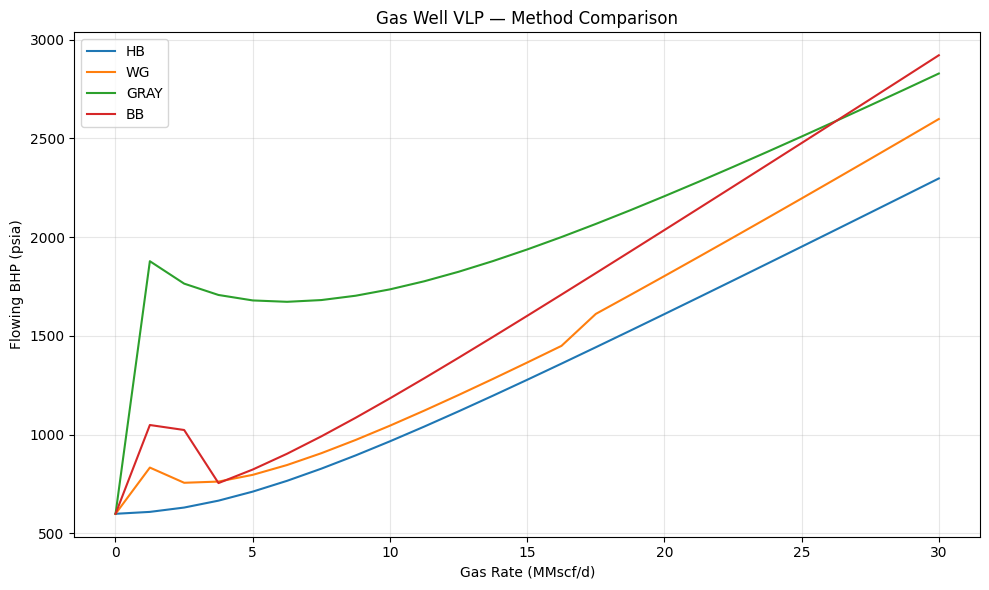

In [7]:
methods = ['HB', 'WG', 'GRAY', 'BB']
colors  = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, ax = plt.subplots()
for m, c in zip(methods, colors):
    v = nodal.outflow_curve(
        thp=thp_gas, completion=comp_field,
        vlpmethod=m, well_type='gas',
        n_rates=25, max_rate=30,
        gsg=gas_pvt_field.sg, cgr=5
    )
    ax.plot(v['rates'], v['bhp'], '-', color=c, label=m)

ax.set_xlabel('Gas Rate (MMscf/d)')
ax.set_ylabel('Flowing BHP (psia)')
ax.set_title('Gas Well VLP — Method Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2c. VLP curve — Metric units

In [8]:
# Metric well
seg_metric = WellSegment(md=2440, id=76, deviation=0, roughness=0.01524, metric=True)
comp_metric = Completion(segments=[seg_metric], tht=38, bht=105, metric=True)

thp_metric = 35  # barsa

vlp_gas_m = nodal.outflow_curve(
    thp=thp_metric, completion=comp_metric,
    vlpmethod='WG', well_type='gas',
    n_rates=25, max_rate=800000,   # sm3/d
    gsg=0.70, cgr=0.00001,         # sm3/sm3
    metric=True
)

print('=== Metric VLP Curve ===')
print(f'Rate range: {vlp_gas_m["rates"][0]:.0f} – {vlp_gas_m["rates"][-1]:.0f} sm3/d')
print(f'BHP range : {min(vlp_gas_m["bhp"]):.1f} – {max(vlp_gas_m["bhp"]):.1f} barsa')
print()
print('First 5 points:')
for i in range(5):
    print(f'  {vlp_gas_m["rates"][i]:10.0f} sm3/d  ->  {vlp_gas_m["bhp"][i]:8.2f} barsa')

=== Metric VLP Curve ===
Rate range: 283 – 800000 sm3/d
BHP range : 41.9 – 154.8 barsa

First 5 points:
         283 sm3/d  ->     41.92 barsa
       33605 sm3/d  ->     58.26 barsa
       66926 sm3/d  ->     52.10 barsa
      100248 sm3/d  ->     51.92 barsa
      133569 sm3/d  ->     53.69 barsa


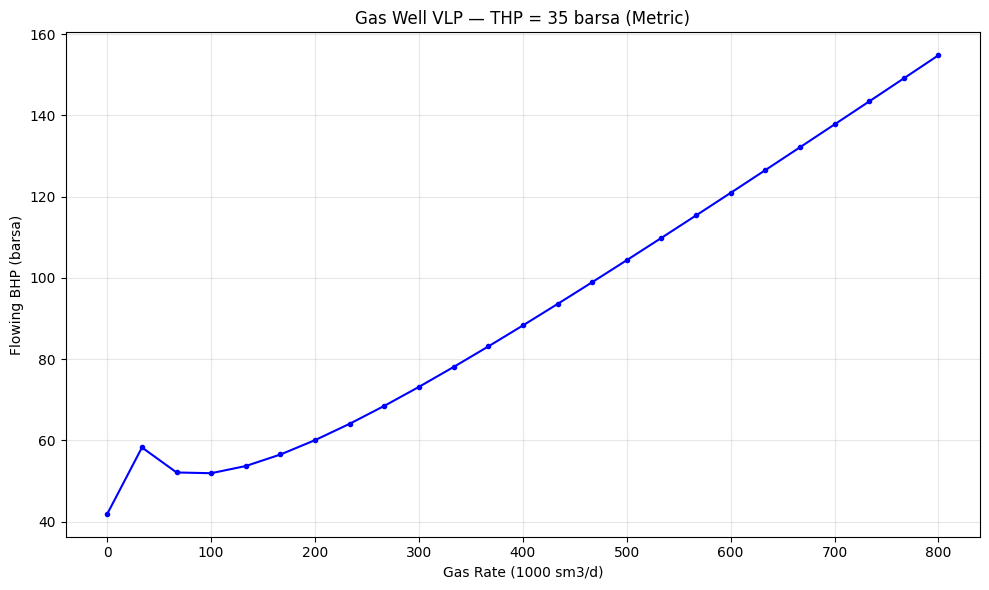

In [9]:
fig, ax = plt.subplots()
ax.plot(np.array(vlp_gas_m['rates'])/1000, vlp_gas_m['bhp'], 'b-o', markersize=3)
ax.set_xlabel('Gas Rate (1000 sm3/d)')
ax.set_ylabel('Flowing BHP (barsa)')
ax.set_title(f'Gas Well VLP — THP = {thp_metric} barsa (Metric)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2d. Oil Well VLP Curve (Field units)

In [10]:
thp_oil = 200  # psia

vlp_oil = nodal.outflow_curve(
    thp=thp_oil, completion=comp_field,
    vlpmethod='BB', well_type='oil',
    n_rates=25, max_rate=8000,
    oil_pvt=oil_pvt_field,
    gor=600, wc=0.1
)

print('=== Oil Well VLP (Field) ===')
print(f'Rate range: {vlp_oil["rates"][0]:.0f} – {vlp_oil["rates"][-1]:.0f} STB/d')
print(f'BHP range : {min(vlp_oil["bhp"]):.0f} – {max(vlp_oil["bhp"]):.0f} psia')
print()
print('First 5 points:')
for i in range(5):
    print(f'  {vlp_oil["rates"][i]:8.0f} STB/d  ->  {vlp_oil["bhp"][i]:8.1f} psia')

=== Oil Well VLP (Field) ===
Rate range: 1 – 8000 STB/d
BHP range : 1620 – 3140 psia

First 5 points:
         1 STB/d  ->    2970.9 psia
       334 STB/d  ->    2491.6 psia
       668 STB/d  ->    1620.2 psia
      1001 STB/d  ->    1630.0 psia
      1334 STB/d  ->    1656.2 psia


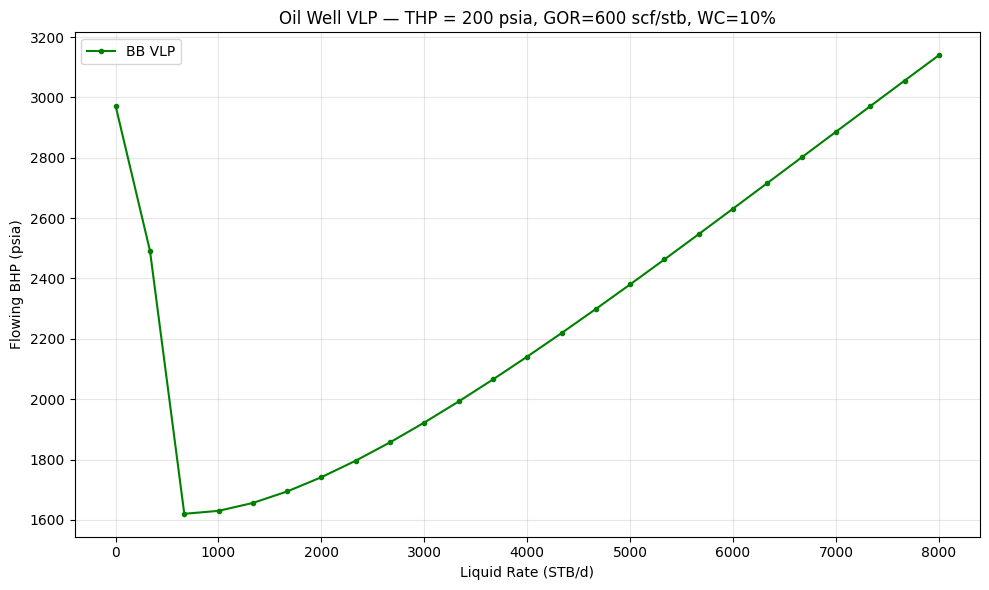

In [11]:
fig, ax = plt.subplots()
ax.plot(vlp_oil['rates'], vlp_oil['bhp'], 'g-o', markersize=3, label='BB VLP')
ax.set_xlabel('Liquid Rate (STB/d)')
ax.set_ylabel('Flowing BHP (psia)')
ax.set_title(f'Oil Well VLP — THP = {thp_oil} psia, GOR=600 scf/stb, WC=10%')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. VFPPROD Table Generation

### 3a. Gas Well VFPPROD (Field units)

In [12]:
vfp_gas = simtools.make_vfpprod(
    table_num=1,
    completion=comp_field,
    well_type='gas',
    vlpmethod='WG',
    flo_rates=[500, 2000, 5000, 10000, 20000, 30000],   # Mscf/d
    thp_values=[300, 500, 800],                          # psia
    wfr_values=[0, 5, 20],                               # stb/Mscf
    gfr_values=[0],                                      # stb/Mscf (no condensate)
    gsg=gas_pvt_field.sg,
    metric=False
)

print('=== VFPPROD Gas (Field) ===')
print(f'Table number : {vfp_gas["table_num"]}')
print(f'Datum depth  : {vfp_gas["datum_depth"]:.0f} ft')
print(f'Well type    : {vfp_gas["well_type"]}')
print(f'FLO type     : {vfp_gas["flo_type"]}')
print(f'WFR type     : {vfp_gas["wfr_type"]}')
print(f'GFR type     : {vfp_gas["gfr_type"]}')
print(f'FLO rates    : {vfp_gas["flo_rates"]}')
print(f'THP values   : {vfp_gas["thp_values"]}')
print(f'WFR values   : {vfp_gas["wfr_values"]}')
print(f'BHP shape    : {vfp_gas["bhp"].shape}')
print(f'Failed calcs : {vfp_gas["n_failed"]}')

=== VFPPROD Gas (Field) ===
Table number : 1
Datum depth  : 8000 ft
Well type    : gas
FLO type     : GAS
WFR type     : WGR
GFR type     : OGR
FLO rates    : [500, 2000, 5000, 10000, 20000, 30000]
THP values   : [300, 500, 800]
WFR values   : [0, 5, 20]
BHP shape    : (3, 3, 1, 1, 6)
Failed calcs : 0


In [13]:
# Show a slice of the BHP array: THP=500, WFR=0, GFR=0, ALQ=0
thp_idx = 1  # THP = 500 psia
print(f'BHP vs Rate at THP={vfp_gas["thp_values"][thp_idx]} psia, WGR=0, OGR=0:')
print(f'{"Rate (Mscf/d)":>15s}  {"BHP (psia)":>12s}')
for i, rate in enumerate(vfp_gas['flo_rates']):
    bhp_val = vfp_gas['bhp'][thp_idx, 0, 0, 0, i]
    print(f'{rate:15.0f}  {bhp_val:12.1f}')

BHP vs Rate at THP=500 psia, WGR=0, OGR=0:
  Rate (Mscf/d)    BHP (psia)
            500         600.6
           2000         619.3
           5000         710.8
          10000         963.2
          20000        1599.1
          30000        2276.6


In [14]:
# Show first 40 lines of the Eclipse keyword string
lines = vfp_gas['eclipse_string'].split('\n')
print('Eclipse VFPPROD keyword (first 40 lines):')
print('\n'.join(lines[:40]))

Eclipse VFPPROD keyword (first 40 lines):
-- Generated by pyResToolbox make_vfpprod
-- Table: 1  Well type: gas  VLP method: WG
-- Completion: 1 segment(s),  Total MD: 8000.0 ft,  Total TVD: 8000.0 ft
--   Segment 1: MD=8000.0 ft,  ID=2.992 in,  deviation=0.0 deg,  roughness=0.0006 in
-- Temperature: THT=100.0 degF,  BHT=220.0 degF
-- Datum depth: 8000.0 ft
-- Fluids: Gas SG=0.7000, Water SG=1.0700, API=45.0
-- THP range: 300.0 - 800.0 psia
-- Flow range: 500.0 - 30000.0 Mscf/d
-- WGR range: 0 - 20 stb/Mscf
-- OGR range: 0 - 0 stb/Mscf
--
VFPPROD
  1  8.00000E+03  GAS  WGR  OGR  THP  ''  FIELD  BHP /
  5.00000E+02  2.00000E+03  5.00000E+03  1.00000E+04  2.00000E+04  3.00000E+04 /
  3.00000E+02  5.00000E+02  8.00000E+02 /
  0.00000E+00  5.00000E+00  2.00000E+01 /
  0.00000E+00 /
  0.00000E+00 /
  1  1  1  1  3.60408E+02  3.91320E+02  5.26000E+02  8.38895E+02  1.53040E+03  2.23005E+03 /
  2  1  1  1  6.00589E+02  6.19323E+02  7.10816E+02  9.63204E+02  1.59910E+03  2.27660E+03 /
  3  1  1

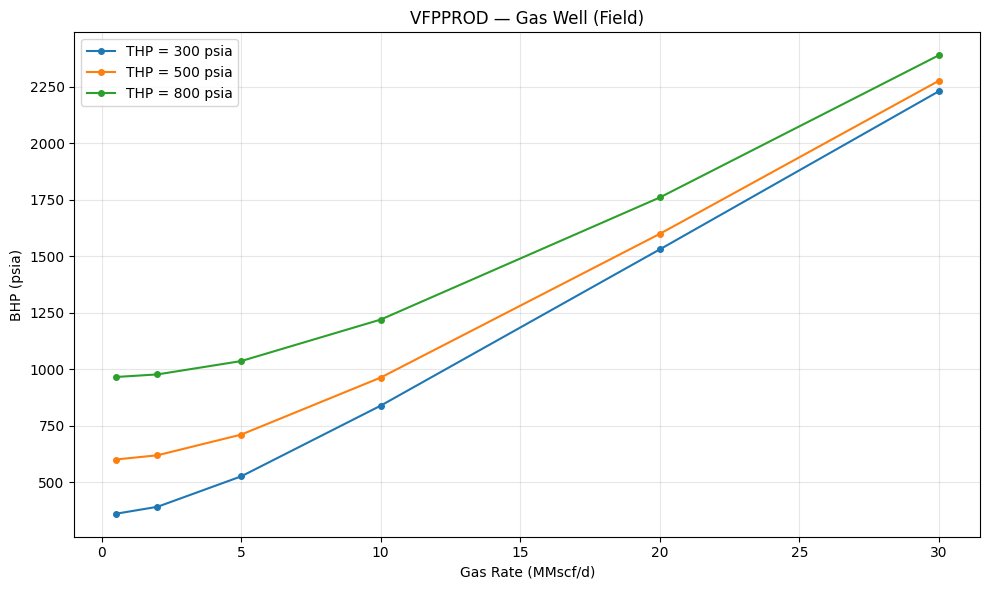

In [15]:
# Plot VFPPROD: BHP vs Rate for each THP, at WGR=0
fig, ax = plt.subplots()
flo = np.array(vfp_gas['flo_rates']) / 1000  # Mscf/d -> MMscf/d for plotting
for t_idx, thp_val in enumerate(vfp_gas['thp_values']):
    bhps = vfp_gas['bhp'][t_idx, 0, 0, 0, :]  # WFR=0, GFR=0, ALQ=0
    ax.plot(flo, bhps, '-o', markersize=4, label=f'THP = {thp_val:.0f} psia')

ax.set_xlabel('Gas Rate (MMscf/d)')
ax.set_ylabel('BHP (psia)')
ax.set_title('VFPPROD — Gas Well (Field)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3b. Oil Well VFPPROD (Metric units)

In [16]:
# Oil completion in metric
seg_oil_m = WellSegment(md=2440, id=76, deviation=0, roughness=0.01524, metric=True)
comp_oil_m = Completion(segments=[seg_oil_m], tht=38, bht=105, metric=True)

vfp_oil = simtools.make_vfpprod(
    table_num=2,
    completion=comp_oil_m,
    well_type='oil',
    vlpmethod='BB',
    flo_rates=[50, 200, 500, 1000, 1500],      # sm3/d
    thp_values=[15, 25, 35],                    # barsa
    wfr_values=[0, 0.3, 0.7],                   # fraction
    gfr_values=[100],                            # sm3/sm3
    oil_pvt=oil_pvt_field,
    metric=True
)

print('=== VFPPROD Oil (Metric) ===')
print(f'Table number : {vfp_oil["table_num"]}')
print(f'Datum depth  : {vfp_oil["datum_depth"]:.0f} m')
print(f'FLO type     : {vfp_oil["flo_type"]}')
print(f'WFR type     : {vfp_oil["wfr_type"]}')
print(f'GFR type     : {vfp_oil["gfr_type"]}')
print(f'FLO rates    : {vfp_oil["flo_rates"]}')
print(f'THP values   : {vfp_oil["thp_values"]}')
print(f'WFR values   : {vfp_oil["wfr_values"]}')
print(f'BHP shape    : {vfp_oil["bhp"].shape}')
print(f'Failed calcs : {vfp_oil["n_failed"]}')

=== VFPPROD Oil (Metric) ===
Table number : 2
Datum depth  : 2440 m
FLO type     : OIL
WFR type     : WCT
GFR type     : GOR
FLO rates    : [50, 200, 500, 1000, 1500]
THP values   : [15, 25, 35]
WFR values   : [0, 0.3, 0.7]
BHP shape    : (3, 3, 1, 1, 5)
Failed calcs : 0


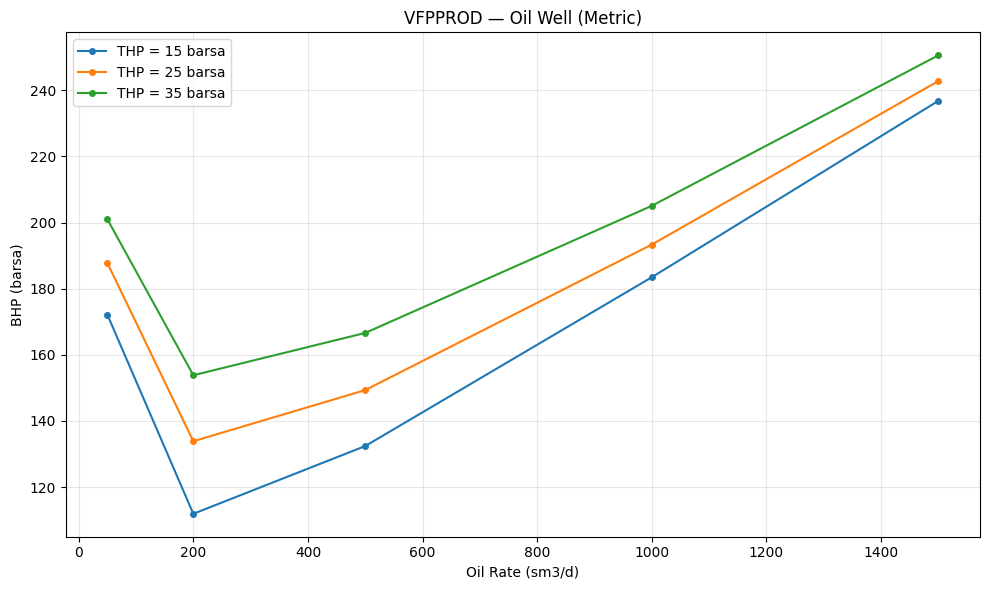

In [17]:
# Plot VFPPROD: BHP vs Rate for each THP, at WCT=0
fig, ax = plt.subplots()
for t_idx, thp_val in enumerate(vfp_oil['thp_values']):
    bhps = vfp_oil['bhp'][t_idx, 0, 0, 0, :]  # WCT=0, GOR[0], ALQ=0
    ax.plot(vfp_oil['flo_rates'], bhps, '-o', markersize=4, label=f'THP = {thp_val:.0f} barsa')

ax.set_xlabel('Oil Rate (sm3/d)')
ax.set_ylabel('BHP (barsa)')
ax.set_title('VFPPROD — Oil Well (Metric)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Nodal Operating Point — Gas Well

### 4a. Gas Well Operating Point (Field)

In [18]:
op_gas = nodal.operating_point(
    thp=500, completion=comp_field,
    reservoir=gas_res_field,
    vlpmethod='WG', well_type='gas',
    gsg=gas_pvt_field.sg, cgr=5
)

print('=== Gas Well Operating Point (Field) ===')
print(f'Operating rate : {op_gas["rate"]:.2f} MMscf/d')
print(f'Operating BHP  : {op_gas["bhp"]:.1f} psia')
print()
print('Return structure keys:', list(op_gas.keys()))
print(f'VLP curve: {len(op_gas["vlp"]["rates"])} points')
print(f'IPR curve: {len(op_gas["ipr"]["rate"])} points')

=== Gas Well Operating Point (Field) ===
Operating rate : 49.69 MMscf/d
Operating BHP  : 3834.4 psia

Return structure keys: ['rate', 'bhp', 'vlp', 'ipr']
VLP curve: 25 points
IPR curve: 25 points


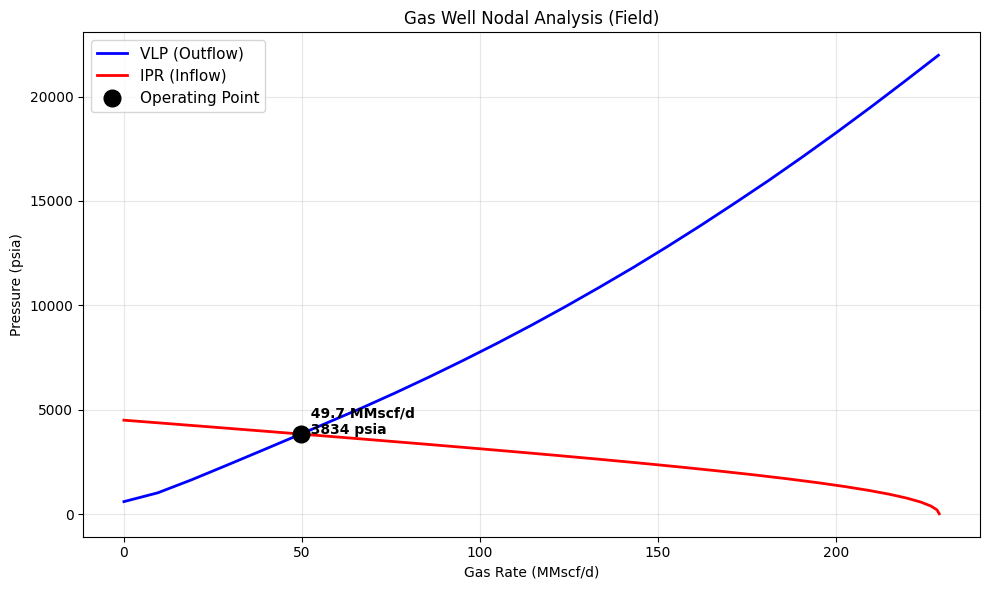

In [19]:
fig, ax = plt.subplots()

# VLP curve (rates in MMscf/d)
ax.plot(op_gas['vlp']['rates'], op_gas['vlp']['bhp'], 'b-', linewidth=2, label='VLP (Outflow)')

# IPR curve (rates in Mscf/d -> convert to MMscf/d)
ipr_rates_mmscfd = np.array(op_gas['ipr']['rate']) / 1000
ax.plot(ipr_rates_mmscfd, op_gas['ipr']['pwf'], 'r-', linewidth=2, label='IPR (Inflow)')

# Operating point
ax.plot(op_gas['rate'], op_gas['bhp'], 'ko', markersize=12, zorder=5, label='Operating Point')
ax.annotate(f'  {op_gas["rate"]:.1f} MMscf/d\n  {op_gas["bhp"]:.0f} psia',
            xy=(op_gas['rate'], op_gas['bhp']),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Gas Rate (MMscf/d)')
ax.set_ylabel('Pressure (psia)')
ax.set_title('Gas Well Nodal Analysis (Field)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4b. Gas Well Operating Point (Metric)

In [20]:
# Metric reservoir
gas_res_metric = Reservoir(pr=310, degf=105, k=50, h=12, re=610, rw=0.108, S=2, metric=True)

op_gas_m = nodal.operating_point(
    thp=35, completion=comp_metric,
    reservoir=gas_res_metric,
    vlpmethod='WG', well_type='gas',
    gsg=0.70, cgr=0.00001,
    metric=True
)

print('=== Gas Well Operating Point (Metric) ===')
print(f'Operating rate : {op_gas_m["rate"]:.0f} sm3/d')
print(f'Operating BHP  : {op_gas_m["bhp"]:.2f} barsa')

=== Gas Well Operating Point (Metric) ===
Operating rate : 1424167 sm3/d
Operating BHP  : 262.72 barsa


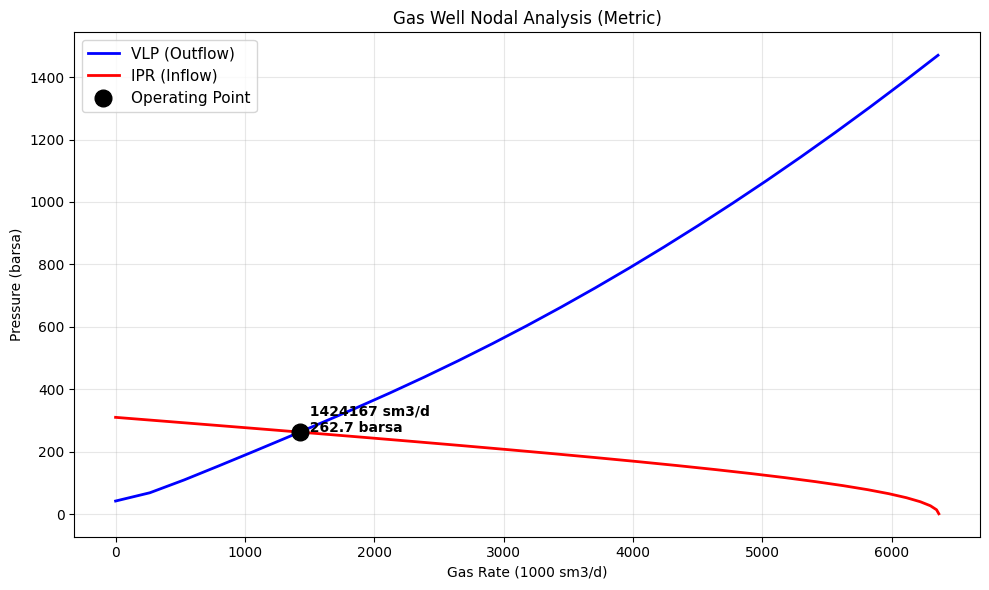

In [21]:
fig, ax = plt.subplots()

# VLP (rates in sm3/d)
vlp_r = np.array(op_gas_m['vlp']['rates']) / 1000  # -> 1000 sm3/d
ax.plot(vlp_r, op_gas_m['vlp']['bhp'], 'b-', linewidth=2, label='VLP (Outflow)')

# IPR (rates in sm3/d)
ipr_r = np.array(op_gas_m['ipr']['rate']) / 1000
ax.plot(ipr_r, op_gas_m['ipr']['pwf'], 'r-', linewidth=2, label='IPR (Inflow)')

# Operating point
op_r = op_gas_m['rate'] / 1000
ax.plot(op_r, op_gas_m['bhp'], 'ko', markersize=12, zorder=5, label='Operating Point')
ax.annotate(f'  {op_gas_m["rate"]:.0f} sm3/d\n  {op_gas_m["bhp"]:.1f} barsa',
            xy=(op_r, op_gas_m['bhp']),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Gas Rate (1000 sm3/d)')
ax.set_ylabel('Pressure (barsa)')
ax.set_title('Gas Well Nodal Analysis (Metric)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4c. Gas Well — THP Sensitivity

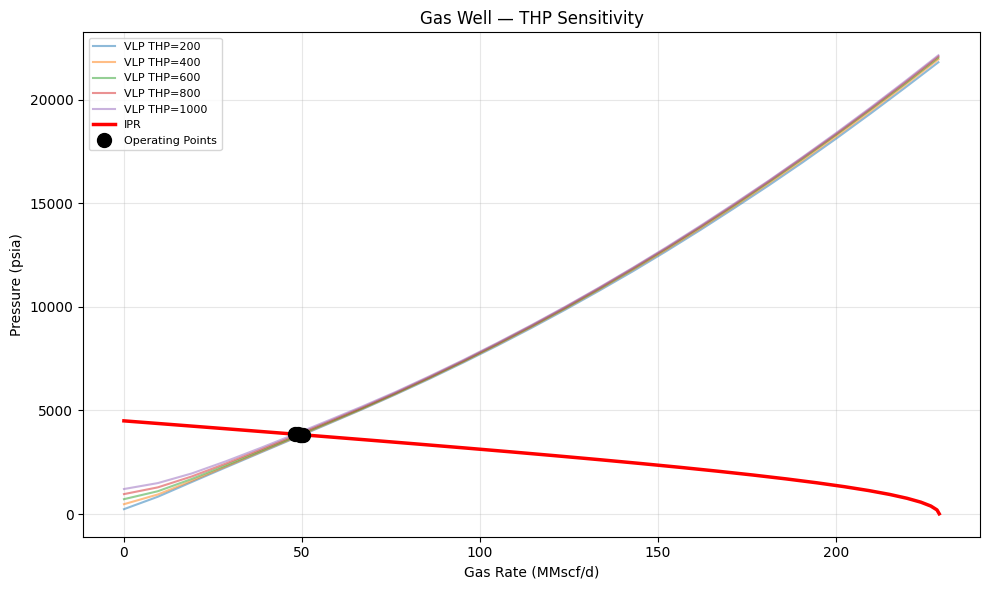

  THP (psia)   Rate (MMscf/d)    BHP (psia)
         200            50.20        3827.4
         400            49.88        3831.7
         600            49.45        3837.6
         800            48.84        3845.8
        1000            48.05        3856.7


In [22]:
thps = [200, 400, 600, 800, 1000]
op_rates = []
op_bhps = []

fig, ax = plt.subplots()

for thp_val in thps:
    op = nodal.operating_point(
        thp=thp_val, completion=comp_field,
        reservoir=gas_res_field,
        vlpmethod='WG', well_type='gas',
        gsg=gas_pvt_field.sg, cgr=5
    )
    op_rates.append(op['rate'])
    op_bhps.append(op['bhp'])
    
    # Plot VLP
    ax.plot(op['vlp']['rates'], op['vlp']['bhp'], '-', alpha=0.5,
            label=f'VLP THP={thp_val}')

# Plot IPR (same for all THPs)
ipr_r = np.array(op['ipr']['rate']) / 1000
ax.plot(ipr_r, op['ipr']['pwf'], 'r-', linewidth=2.5, label='IPR')

# Plot all operating points
ax.plot(op_rates, op_bhps, 'ko', markersize=10, zorder=5, label='Operating Points')

ax.set_xlabel('Gas Rate (MMscf/d)')
ax.set_ylabel('Pressure (psia)')
ax.set_title('Gas Well — THP Sensitivity')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'{"THP (psia)":>12s}  {"Rate (MMscf/d)":>15s}  {"BHP (psia)":>12s}')
for t, r, b in zip(thps, op_rates, op_bhps):
    print(f'{t:12.0f}  {r:15.2f}  {b:12.1f}')

---
## 5. Nodal Operating Point — Oil Well

### 5a. Oil Well Operating Point (Field)

In [23]:
op_oil = nodal.operating_point(
    thp=200, completion=comp_field,
    reservoir=oil_res_field,
    vlpmethod='BB', well_type='oil',
    oil_pvt=oil_pvt_field,
    gor=600, wc=0.1
)

print('=== Oil Well Operating Point (Field) ===')
print(f'Operating rate : {op_oil["rate"]:.1f} STB/d')
print(f'Operating BHP  : {op_oil["bhp"]:.1f} psia')
print()
print('Return structure keys:', list(op_oil.keys()))
print(f'VLP curve: {len(op_oil["vlp"]["rates"])} points')
print(f'IPR curve: {len(op_oil["ipr"]["rate"])} points')

=== Oil Well Operating Point (Field) ===
Operating rate : 8953.5 STB/d
Operating BHP  : 3378.4 psia

Return structure keys: ['rate', 'bhp', 'vlp', 'ipr']
VLP curve: 25 points
IPR curve: 25 points


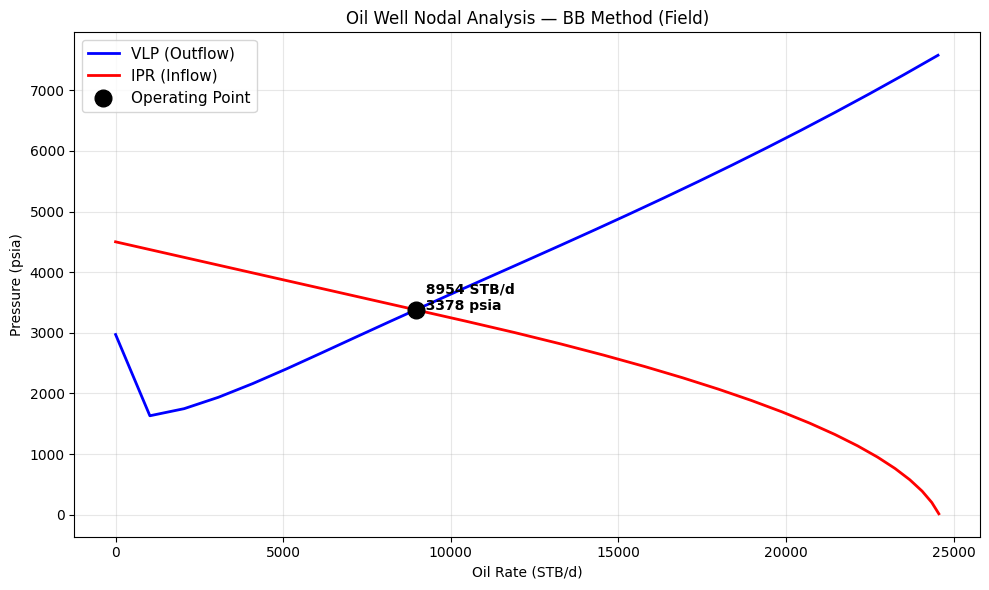

In [24]:
fig, ax = plt.subplots()

# VLP
ax.plot(op_oil['vlp']['rates'], op_oil['vlp']['bhp'], 'b-', linewidth=2, label='VLP (Outflow)')

# IPR (oil rates in STB/d — same units as VLP for oil)
ax.plot(op_oil['ipr']['rate'], op_oil['ipr']['pwf'], 'r-', linewidth=2, label='IPR (Inflow)')

# Operating point
ax.plot(op_oil['rate'], op_oil['bhp'], 'ko', markersize=12, zorder=5, label='Operating Point')
ax.annotate(f'  {op_oil["rate"]:.0f} STB/d\n  {op_oil["bhp"]:.0f} psia',
            xy=(op_oil['rate'], op_oil['bhp']),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Oil Rate (STB/d)')
ax.set_ylabel('Pressure (psia)')
ax.set_title('Oil Well Nodal Analysis — BB Method (Field)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5b. Oil Well — Water Cut Sensitivity

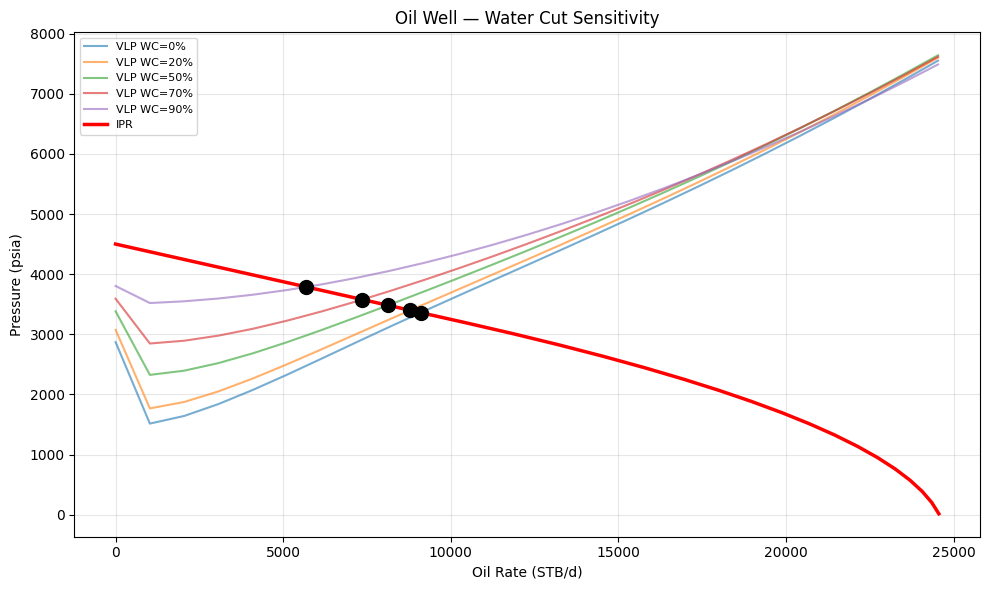

    WC   Rate (STB/d)    BHP (psia)
    0%         9101.1        3359.9
   20%         8789.6        3398.9
   50%         8127.8        3481.8
   70%         7363.4        3577.6
   90%         5694.2        3786.7


In [25]:
watercuts = [0.0, 0.2, 0.5, 0.7, 0.9]
wc_rates = []
wc_bhps = []

fig, ax = plt.subplots()

for wc_val in watercuts:
    op = nodal.operating_point(
        thp=200, completion=comp_field,
        reservoir=oil_res_field,
        vlpmethod='BB', well_type='oil',
        oil_pvt=oil_pvt_field,
        gor=600, wc=wc_val
    )
    wc_rates.append(op['rate'])
    wc_bhps.append(op['bhp'])
    
    ax.plot(op['vlp']['rates'], op['vlp']['bhp'], '-', alpha=0.6,
            label=f'VLP WC={wc_val:.0%}')

# IPR (same for all WC)
ax.plot(op['ipr']['rate'], op['ipr']['pwf'], 'r-', linewidth=2.5, label='IPR')
ax.plot(wc_rates, wc_bhps, 'ko', markersize=10, zorder=5)

ax.set_xlabel('Oil Rate (STB/d)')
ax.set_ylabel('Pressure (psia)')
ax.set_title('Oil Well — Water Cut Sensitivity')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'{"WC":>6s}  {"Rate (STB/d)":>13s}  {"BHP (psia)":>12s}')
for wc_val, r, b in zip(watercuts, wc_rates, wc_bhps):
    print(f'{wc_val:6.0%}  {r:13.1f}  {b:12.1f}')

---
## 6. Hydrate Analysis of the Nodal Systems

Analyse hydrate risk at the wellhead conditions predicted by the nodal solutions above.

### 6a. Gas Well Hydrate Assessment (Field)

The wellhead at 100 degF is above the HFT — no hydrate risk there. But the gas then enters a subsea pipeline where it cools to ~60 degF. Assess hydrate risk at pipeline conditions.

In [ ]:
# Pipeline conditions downstream of wellhead (subsea scenario)
pipe_p = thp_gas              # 500 psia (roughly same as wellhead)
pipe_t = 60                   # degF — gas has cooled in the pipeline
res_p = gas_res_field.pr      # 4500 psia
res_t = gas_res_field.degf    # 220 degF

hyd = gas_hydrate(
    p=pipe_p, degf=pipe_t, sg=gas_pvt_field.sg,
    co2=gas_pvt_field.co2, h2s=gas_pvt_field.h2s,
    n2=gas_pvt_field.n2,
    p_res=res_p, degf_res=res_t,
    additional_water=0.5,          # 0.5 stb/MMscf free water from reservoir
    hydmethod='MOTIEE',
    inhibitor_type='MEG',
    inhibitor_wt_pct=25
)

print('=== Gas Hydrate Assessment — Subsea Pipeline (Field) ===')
print(f'  Pipeline P,T  : {pipe_p} psia, {pipe_t} degF')
print(f'  Reservoir P,T : {res_p} psia, {res_t} degF')
print()
print('--- Hydrate Window ---')
print(f'  HFT              : {hyd.hft:.1f} degF')
print(f'  HFP              : {hyd.hfp:.1f} psia')
print(f'  Subcooling       : {hyd.subcooling:.1f} degF')
print(f'  In hydrate window: {hyd.in_hydrate_window}')
print()
print('--- Inhibitor (MEG applied at 25 wt%) ---')
print(f'  Inhibited HFT    : {hyd.inhibited_hft:.1f} degF')
print(f'  Depression       : {hyd.inhibitor_depression:.1f} degF')
print(f'  Protected?       : {hyd.inhibited_hft < pipe_t}'
      f'  (inhibited HFT {"<" if hyd.inhibited_hft < pipe_t else ">"} operating T)')
print(f'  Required wt%     : {hyd.required_inhibitor_wt_pct:.1f}'
      f'  (concentration needed to fully depress HFT below {pipe_t} degF)')
print(f'  Max wt% (MEG)    : {hyd.max_inhibitor_wt_pct:.0f}'
      f'  (physical ceiling for MEG)')
print(f'  Inhibitor limited: {hyd.inhibitor_underdosed}'
      f'  (True = required wt% exceeds physical max → inhibitor type is insufficient)')
print()
print('--- Water Balance (stb/MMscf) ---')
print(f'  Vaporized (res)  : {hyd.water_vaporized_res:.4f}')
print(f'  Vaporized (op)   : {hyd.water_vaporized_op:.4f}')
print(f'  Condensed        : {hyd.water_condensed:.4f}')
print(f'  Free water       : {hyd.free_water:.4f}')
print(f'  Total liquid     : {hyd.total_liquid_water:.4f}')
print()
print('--- Injection Rate ---')
print(f'  Mass rate        : {hyd.inhibitor_mass_rate:.2f} lb/MMscf')
print(f'  Volume rate      : {hyd.inhibitor_vol_rate:.2f} gal/MMscf')
print()
print('Note: We are dosing 25 wt% MEG but need 58.1 wt% to fully protect.')
print('The inhibited HFT (77.8 degF) is still above the pipeline T (60 degF).')
print('"Inhibitor limited" is False because MEG *can* reach 58.1 wt% (< 70% max).')
print('Increase dosing to ~58 wt% MEG for full protection.')

In [27]:
# Inspect the full HydrateResult dataclass
print('All HydrateResult fields:')
from dataclasses import fields
for f in fields(hyd):
    val = getattr(hyd, f.name)
    if isinstance(val, float):
        print(f'  {f.name:30s} = {val:.6f}')
    else:
        print(f'  {f.name:30s} = {val}')

All HydrateResult fields:
  hft                            = 88.849243
  hfp                            = 115.655473
  subcooling                     = 28.849243
  in_hydrate_window              = True
  inhibited_hft                  = 77.838306
  inhibitor_depression           = 11.010938
  required_inhibitor_wt_pct      = 58.075445
  max_inhibitor_wt_pct           = 70.000000
  inhibitor_underdosed           = False
  water_vaporized_res            = 1.062537
  water_vaporized_op             = 0.082842
  water_condensed                = 0.979696
  free_water                     = 0.500000
  total_liquid_water             = 1.479696
  inhibitor_mass_rate            = 717.815116
  inhibitor_vol_rate             = 77.489388


### 6b. Compare Inhibitors at Pipeline Conditions

In [28]:
inhibitors = ['MEOH', 'MEG', 'DEG', 'TEG', 'ETOH']

print(f'Pipeline: {pipe_p} psia, {pipe_t} degF  |  Reservoir: {res_p} psia, {res_t} degF')
print(f'Free water: 0.5 stb/MMscf  |  HFT = {hyd.hft:.1f} degF')
print()
print(f'{"Inhibitor":>10s}  {"Max wt%":>8s}  {"Req wt%":>8s}  {"Underdosed":>11s}'
      f'  {"Mass Rate":>12s}  {"Vol Rate":>12s}')
print(f'{"":>10s}  {"":>8s}  {"":>8s}  {"":>11s}'
      f'  {"(lb/MMscf)":>12s}  {"(gal/MMscf)":>12s}')
print('-' * 75)

# Pre-compute all results before printing to avoid Jupyter stdout buffer splits
rows = []
for inh in inhibitors:
    h = gas_hydrate(
        p=pipe_p, degf=pipe_t, sg=gas_pvt_field.sg,
        co2=gas_pvt_field.co2, h2s=gas_pvt_field.h2s, n2=gas_pvt_field.n2,
        p_res=res_p, degf_res=res_t,
        additional_water=0.5,
        inhibitor_type=inh
    )
    rows.append(f'{inh:>10s}  {h.max_inhibitor_wt_pct:8.0f}  {h.required_inhibitor_wt_pct:8.1f}'
                f'  {str(h.inhibitor_underdosed):>11s}  {h.inhibitor_mass_rate:12.2f}'
                f'  {h.inhibitor_vol_rate:12.2f}')

print('\n'.join(rows))
print()
print('Note: MEOH, DEG, TEG, ETOH are underdosed — their required concentration')
print('exceeds the physical maximum. Only MEG at 58.1 wt% can fully inhibit.')

Pipeline: 500 psia, 60 degF  |  Reservoir: 4500 psia, 220 degF
Free water: 0.5 stb/MMscf  |  HFT = 88.8 degF

 Inhibitor   Max wt%   Req wt%   Underdosed     Mass Rate      Vol Rate
                                               (lb/MMscf)   (gal/MMscf)
---------------------------------------------------------------------------
      MEOH        25      25.0         True        172.73         26.17
       MEG        70      58.1        False        717.82         77.49
       DEG        70      70.0         True       1209.11        129.71
       TEG        50      50.0         True        518.19         55.19
      ETOH        30      30.0         True        222.08         33.73

Note: MEOH, DEG, TEG, ETOH are underdosed — their required concentration
exceeds the physical maximum. Only MEG at 58.1 wt% can fully inhibit.


### 6c. Hydrate Envelope — HFT vs Pressure Curve

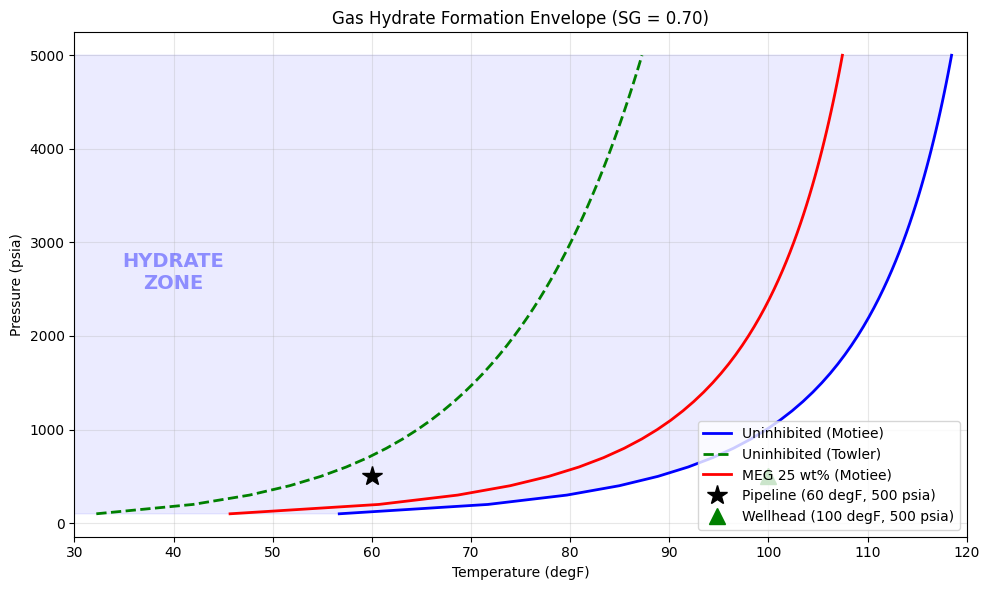

In [29]:
pressures = np.linspace(100, 5000, 50)
hft_motiee = []
hft_towler = []
hft_meg25 = []

for p in pressures:
    r1 = gas_hydrate(p=p, degf=60, sg=0.70, hydmethod='MOTIEE')
    r2 = gas_hydrate(p=p, degf=60, sg=0.70, hydmethod='TOWLER')
    r3 = gas_hydrate(p=p, degf=60, sg=0.70, hydmethod='MOTIEE',
                      inhibitor_type='MEG', inhibitor_wt_pct=25)
    hft_motiee.append(r1.hft)
    hft_towler.append(r2.hft)
    hft_meg25.append(r3.inhibited_hft)

fig, ax = plt.subplots()
ax.plot(hft_motiee, pressures, 'b-', linewidth=2, label='Uninhibited (Motiee)')
ax.plot(hft_towler, pressures, 'g--', linewidth=2, label='Uninhibited (Towler)')
ax.plot(hft_meg25, pressures, 'r-', linewidth=2, label='MEG 25 wt% (Motiee)')

# Mark the pipeline operating point and wellhead
ax.plot(pipe_t, pipe_p, 'k*', markersize=15, zorder=5,
        label=f'Pipeline ({pipe_t} degF, {pipe_p} psia)')
ax.plot(comp_field.tht, thp_gas, 'g^', markersize=12, zorder=5,
        label=f'Wellhead ({comp_field.tht:.0f} degF, {thp_gas} psia)')

ax.fill_betweenx(pressures, 0, hft_motiee, alpha=0.08, color='blue', label='_nolegend_')
ax.text(40, 2500, 'HYDRATE\nZONE', fontsize=14, fontweight='bold', color='blue', alpha=0.4,
        ha='center')

ax.set_xlabel('Temperature (degF)')
ax.set_ylabel('Pressure (psia)')
ax.set_title('Gas Hydrate Formation Envelope (SG = 0.70)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(30, 120)
plt.tight_layout()
plt.show()

### 6d. Hydrate Assessment — Metric Units

In [30]:
# Subsea pipeline scenario in metric units
# Pipeline at 35 barsa, 15 degC (59 degF equivalent — in hydrate window)
hyd_m = gas_hydrate(
    p=35, degf=15, sg=0.70,
    co2=0.03, h2s=0.01, n2=0.02,
    p_res=310, degf_res=105,
    additional_water=0.0001,   # sm3/sm3
    inhibitor_type='MEG',
    inhibitor_wt_pct=25,
    metric=True
)

print('=== Pipeline Hydrate Assessment (Metric) ===')
print(f'  Pipeline P,T  : 35 barsa, 15 degC')
print(f'  Reservoir P,T : 310 barsa, 105 degC')
print()
print('--- Hydrate Window ---')
print(f'  HFT              : {hyd_m.hft:.2f} degC')
print(f'  HFP              : {hyd_m.hfp:.2f} barsa')
print(f'  Subcooling       : {hyd_m.subcooling:.2f} degC')
print(f'  In hydrate window: {hyd_m.in_hydrate_window}')
print()
print('--- Inhibitor (MEG at 25 wt%) ---')
print(f'  Inhibited HFT    : {hyd_m.inhibited_hft:.2f} degC')
print(f'  Depression       : {hyd_m.inhibitor_depression:.2f} degC')
print(f'  Required wt%     : {hyd_m.required_inhibitor_wt_pct:.1f}')
print(f'  Underdosed?      : {hyd_m.inhibitor_underdosed}')
print()
print('--- Water Balance (sm3/sm3) ---')
print(f'  Vaporized (res)  : {hyd_m.water_vaporized_res:.6f}')
print(f'  Vaporized (op)   : {hyd_m.water_vaporized_op:.6f}')
print(f'  Condensed        : {hyd_m.water_condensed:.6f}')
print(f'  Free water       : {hyd_m.free_water:.6f}')
print(f'  Total liquid     : {hyd_m.total_liquid_water:.6f}')
print()
print('--- Injection Rate ---')
print(f'  Mass rate        : {hyd_m.inhibitor_mass_rate:.4f} kg/sm3')
print(f'  Volume rate      : {hyd_m.inhibitor_vol_rate:.4f} L/sm3')

=== Pipeline Hydrate Assessment (Metric) ===
  Pipeline P,T  : 35 barsa, 15 degC
  Reservoir P,T : 310 barsa, 105 degC

--- Hydrate Window ---
  HFT              : 31.73 degC
  HFP              : 7.63 barsa
  Subcooling       : 16.73 degC
  In hydrate window: True

--- Inhibitor (MEG at 25 wt%) ---
  Inhibited HFT    : 25.61 degC
  Depression       : 6.12 degC
  Required wt%     : 59.9
  Underdosed?      : False

--- Water Balance (sm3/sm3) ---
  Vaporized (res)  : 0.000006
  Vaporized (op)   : 0.000000
  Condensed        : 0.000006
  Free water       : 0.000100
  Total liquid     : 0.000106

--- Injection Rate ---
  Mass rate        : 0.1578 kg/sm3
  Volume rate      : 0.1421 L/sm3


### 6e. Water Balance Waterfall — Reservoir to Wellhead

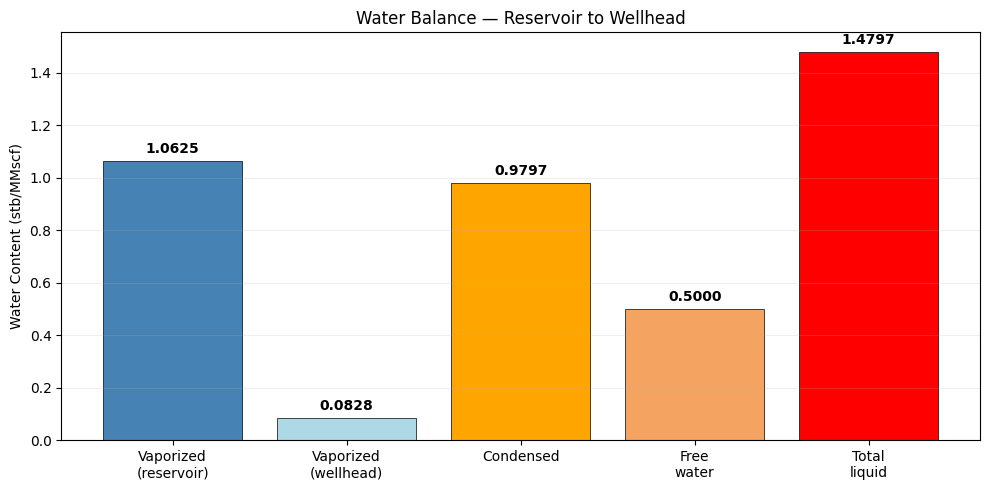

In [31]:
# Use the Field hydrate result (hyd) from section 6a
labels = ['Vaporized\n(reservoir)', 'Vaporized\n(wellhead)', 'Condensed', 'Free\nwater', 'Total\nliquid']
values = [hyd.water_vaporized_res, hyd.water_vaporized_op, hyd.water_condensed,
          hyd.free_water, hyd.total_liquid_water]
colors_bar = ['steelblue', 'lightblue', 'orange', 'sandybrown', 'red']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors_bar, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Water Content (stb/MMscf)')
ax.set_title('Water Balance — Reservoir to Wellhead')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

### 6f. Impact of Reservoir P,T on Condensed Water and Injection Rate

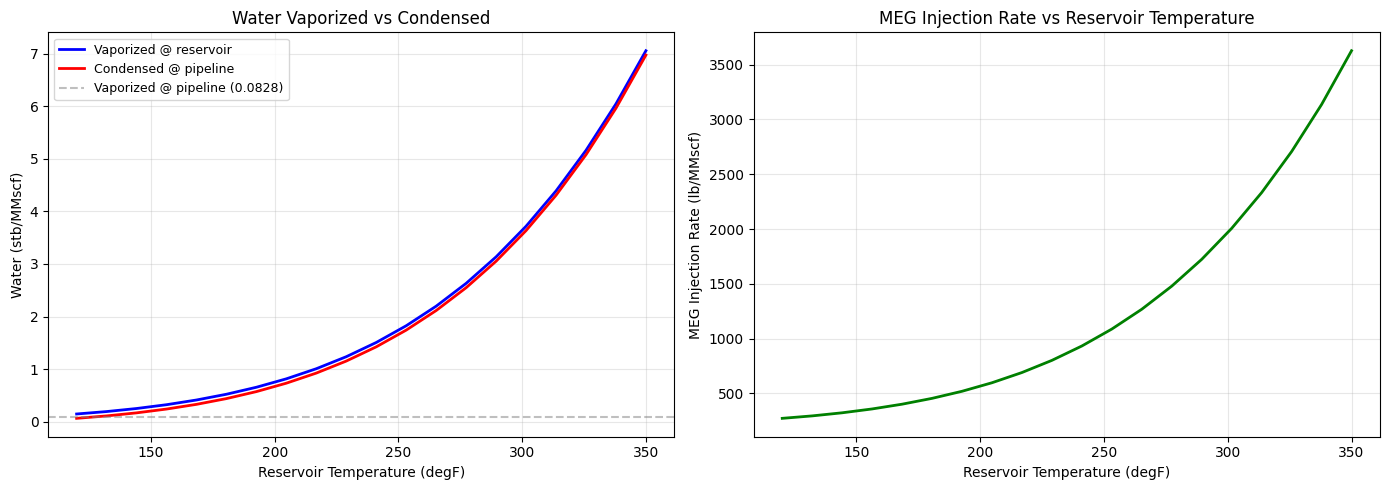

In [32]:
# Vary reservoir temperature at fixed Pr=4500 psia, pipeline at 500 psia / 60 degF
res_temps = np.linspace(120, 350, 20)  # degF
condensed_list = []
mass_rate_list = []
vap_res_list = []

for t_res in res_temps:
    h = gas_hydrate(
        p=500, degf=60, sg=0.70,
        co2=0.03, h2s=0.01, n2=0.02,
        p_res=4500, degf_res=t_res,
        additional_water=0.5,
        inhibitor_type='MEG'
    )
    vap_res_list.append(h.water_vaporized_res)
    condensed_list.append(h.water_condensed)
    mass_rate_list.append(h.inhibitor_mass_rate)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(res_temps, vap_res_list, 'b-', linewidth=2, label='Vaporized @ reservoir')
ax1.plot(res_temps, condensed_list, 'r-', linewidth=2, label='Condensed @ pipeline')
ax1.axhline(y=hyd.water_vaporized_op, color='gray', linestyle='--', alpha=0.5,
            label=f'Vaporized @ pipeline ({hyd.water_vaporized_op:.4f})')
ax1.set_xlabel('Reservoir Temperature (degF)')
ax1.set_ylabel('Water (stb/MMscf)')
ax1.set_title('Water Vaporized vs Condensed')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(res_temps, mass_rate_list, 'g-', linewidth=2)
ax2.set_xlabel('Reservoir Temperature (degF)')
ax2.set_ylabel('MEG Injection Rate (lb/MMscf)')
ax2.set_title('MEG Injection Rate vs Reservoir Temperature')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6g. Hydrate Risk Along Wellbore — Flowing Temperature Profile

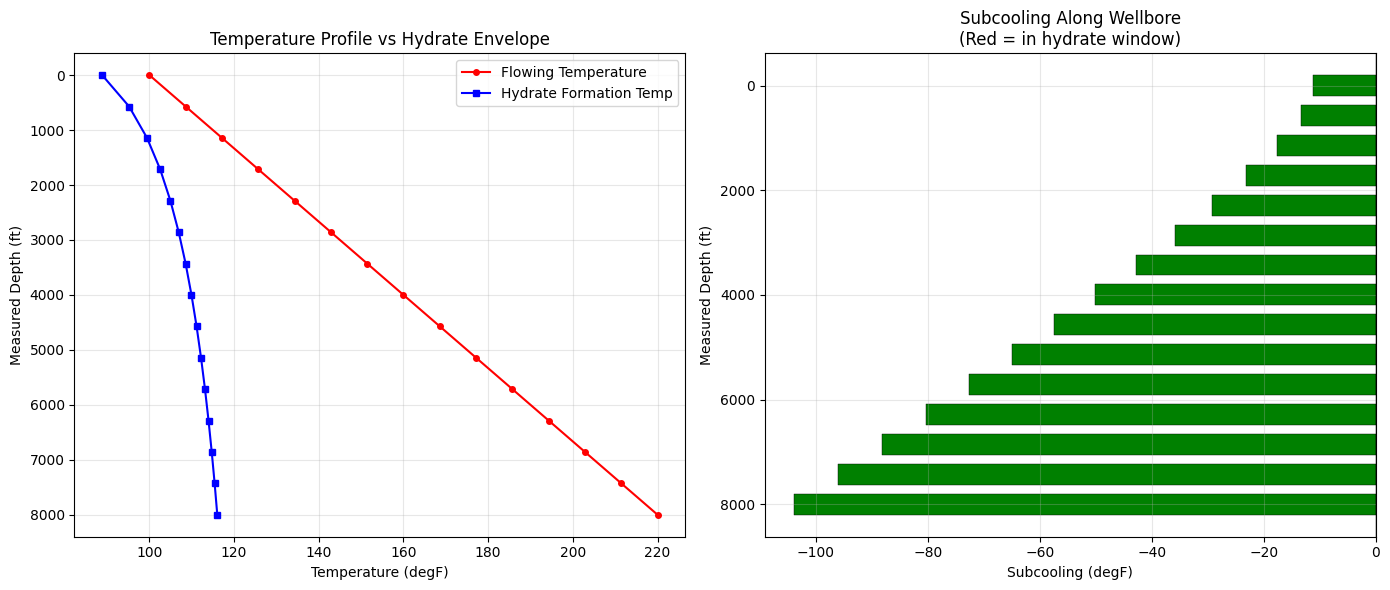

 MD (ft)    P (psia)    T (degF)   HFT (degF)    Subcool   In Window
----------------------------------------------------------------------
    8000      3834.4       220.0        116.0     -104.0       False
    7429      3596.2       211.4        115.4      -96.0       False
    6857      3358.0       202.9        114.7      -88.1       False
    6286      3119.9       194.3        114.0      -80.3       False
    5714      2881.7       185.7        113.1      -72.6       False
    5143      2643.5       177.1        112.2      -64.9       False
    4571      2405.4       168.6        111.1      -57.4       False
    4000      2167.2       160.0        109.9      -50.1       False
    3429      1929.0       151.4        108.6      -42.9       False
    2857      1690.9       142.9        106.9      -35.9       False
    2286      1452.7       134.3        105.0      -29.3       False
    1714      1214.5       125.7        102.5      -23.2       False
    1143       976.3       117.1

In [33]:
# Simulate hydrate risk at several points along the wellbore
# Assume linear P and T profiles from BHP/BHT to THP/THT
gas_op_rate = op_gas['rate']  # MMscf/d
gas_op_bhp = op_gas['bhp']   # psia

n_pts = 15
md_fracs = np.linspace(0, 1, n_pts)  # 0 = bottom, 1 = top
md_pts = comp_field.total_md * (1 - md_fracs)  # MD from surface
p_pts = gas_op_bhp + (thp_gas - gas_op_bhp) * md_fracs
t_pts = comp_field.bht + (comp_field.tht - comp_field.bht) * md_fracs

hft_pts = []
subcool_pts = []
in_window_pts = []

for p_val, t_val in zip(p_pts, t_pts):
    h = gas_hydrate(p=p_val, degf=t_val, sg=0.70)
    hft_pts.append(h.hft)
    subcool_pts.append(h.subcooling)
    in_window_pts.append(h.in_hydrate_window)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: T profile vs HFT profile
ax1.plot(t_pts, md_pts, 'r-o', markersize=4, label='Flowing Temperature')
ax1.plot(hft_pts, md_pts, 'b-s', markersize=4, label='Hydrate Formation Temp')
for i in range(n_pts):
    if in_window_pts[i]:
        ax1.plot(t_pts[i], md_pts[i], 'rx', markersize=12, markeredgewidth=2)
ax1.set_xlabel('Temperature (degF)')
ax1.set_ylabel('Measured Depth (ft)')
ax1.set_title('Temperature Profile vs Hydrate Envelope')
ax1.invert_yaxis()
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Subcooling profile
col = ['red' if s > 0 else 'green' for s in subcool_pts]
ax2.barh(md_pts, subcool_pts, height=400, color=col, edgecolor='black', linewidth=0.3)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_xlabel('Subcooling (degF)')
ax2.set_ylabel('Measured Depth (ft)')
ax2.set_title('Subcooling Along Wellbore\n(Red = in hydrate window)')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'{"MD (ft)":>8s}  {"P (psia)":>10s}  {"T (degF)":>10s}  {"HFT (degF)":>11s}'
      f'  {"Subcool":>9s}  {"In Window":>10s}')
print('-' * 70)
for i in range(n_pts):
    print(f'{md_pts[i]:8.0f}  {p_pts[i]:10.1f}  {t_pts[i]:10.1f}  {hft_pts[i]:11.1f}'
          f'  {subcool_pts[i]:9.1f}  {str(in_window_pts[i]):>10s}')

### 6h. Oil Well Hydrate Check

In [34]:
# Hydrate check at the oil well THP / THT
# Oil wells produce associated gas — use separator gas SG
hyd_oil = gas_hydrate(
    p=200, degf=comp_field.tht, sg=oil_pvt_field.sg_sp,
    p_res=oil_res_field.pr, degf_res=oil_res_field.degf,
    inhibitor_type='MEOH'
)

print('=== Oil Well Hydrate Check (Field) ===')
print(f'  Wellhead P,T     : 200 psia, {comp_field.tht} degF')
print(f'  Gas SG (sep)     : {oil_pvt_field.sg_sp}')
print(f'  HFT              : {hyd_oil.hft:.1f} degF')
print(f'  In hydrate window: {hyd_oil.in_hydrate_window}')
print(f'  Subcooling       : {hyd_oil.subcooling:.1f} degF')
if hyd_oil.in_hydrate_window:
    print(f'  Required MEOH    : {hyd_oil.required_inhibitor_wt_pct:.1f} wt%')
    print(f'  MEOH underdosed  : {hyd_oil.inhibitor_underdosed}')
    print(f'  Mass rate        : {hyd_oil.inhibitor_mass_rate:.2f} lb/MMscf')
else:
    print('  No hydrate risk at these conditions.')

=== Oil Well Hydrate Check (Field) ===
  Wellhead P,T     : 200 psia, 100 degF
  Gas SG (sep)     : 0.65
  HFT              : 66.4 degF
  In hydrate window: False
  Subcooling       : -33.6 degF
  No hydrate risk at these conditions.


---
## 7. Multi-Segment Deviated Well Example

Demonstrate a deviated/horizontal well with multiple segments, including nodal solution and hydrate check.

In [35]:
# 3-segment deviated gas well
seg1 = WellSegment(md=5000, id=2.992, deviation=0)       # Vertical to KOP
seg2 = WellSegment(md=2000, id=2.992, deviation=45)      # Build section
seg3 = WellSegment(md=3000, id=2.441, deviation=85)      # Near-horizontal lateral

comp_dev = Completion(segments=[seg1, seg2, seg3], tht=90, bht=240)

print('=== Deviated Well Geometry ===')
print(f'  Total MD  : {comp_dev.total_md:.0f} ft')
print(f'  Total TVD : {comp_dev.total_tvd:.0f} ft')
print()
print('Profile:')
print(comp_dev.profile())

=== Deviated Well Geometry ===
  Total MD  : 10000 ft
  Total TVD : 6676 ft

Profile:
        MD          TVD  Deviation     ID  Roughness
0      0.0     0.000000          0  2.992     0.0006
1   5000.0  5000.000000          0  2.992     0.0006
2   5000.0  5000.000000         45  2.992     0.0006
3   7000.0  6414.213562         45  2.992     0.0006
4   7000.0  6414.213562         85  2.441     0.0006
5  10000.0  6675.680791         85  2.441     0.0006


BB: Rate = 33.82 MMscf/d, BHP = 4444 psia
WG: Rate = 40.05 MMscf/d, BHP = 4341 psia


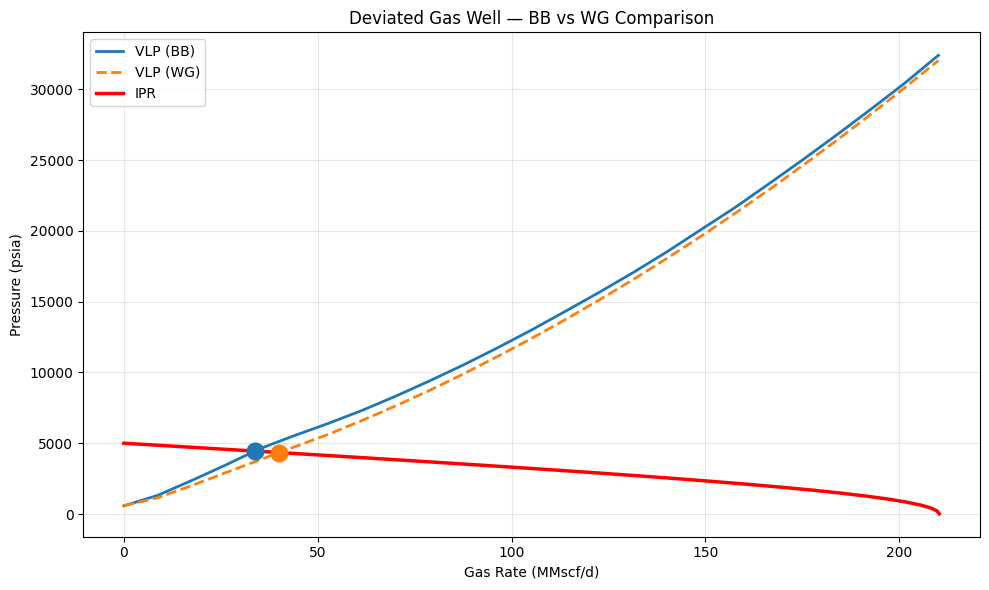

In [36]:
# Reservoir for deviated well
res_dev = Reservoir(pr=5000, degf=240, k=30, h=60, re=2000, rw=0.354, S=3)

# Operating point — compare BB (suitable for deviated) vs WG
fig, ax = plt.subplots()

for method, color, ls in [('BB', 'tab:blue', '-'), ('WG', 'tab:orange', '--')]:
    op = nodal.operating_point(
        thp=500, completion=comp_dev,
        reservoir=res_dev,
        vlpmethod=method, well_type='gas',
        gsg=0.70, cgr=5
    )
    
    ax.plot(op['vlp']['rates'], op['vlp']['bhp'], ls, color=color, linewidth=2,
            label=f'VLP ({method})')
    ax.plot(op['rate'], op['bhp'], 'o', color=color, markersize=12, zorder=5)
    print(f'{method}: Rate = {op["rate"]:.2f} MMscf/d, BHP = {op["bhp"]:.0f} psia')

# IPR
ipr_r = np.array(op['ipr']['rate']) / 1000
ax.plot(ipr_r, op['ipr']['pwf'], 'r-', linewidth=2.5, label='IPR')

ax.set_xlabel('Gas Rate (MMscf/d)')
ax.set_ylabel('Pressure (psia)')
ax.set_title('Deviated Gas Well — BB vs WG Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Hydrate check for the deviated well — subsea pipeline at 60 degF
hyd_dev = gas_hydrate(
    p=500, degf=60, sg=0.70,
    co2=0.03, h2s=0.01, n2=0.02,
    p_res=5000, degf_res=240,
    additional_water=1.0,
    inhibitor_type='MEG'
)

print('=== Deviated Well — Pipeline Hydrate Check ===')
print(f'  Pipeline P,T     : 500 psia, 60 degF')
print(f'  Reservoir P,T    : 5000 psia, 240 degF')
print(f'  HFT              : {hyd_dev.hft:.1f} degF')
print(f'  In hydrate window: {hyd_dev.in_hydrate_window}')
print(f'  Subcooling       : {hyd_dev.subcooling:.1f} degF')
print()
print('--- Water Balance (stb/MMscf) ---')
print(f'  Vaporized (res)  : {hyd_dev.water_vaporized_res:.4f}')
print(f'  Vaporized (op)   : {hyd_dev.water_vaporized_op:.4f}')
print(f'  Condensed        : {hyd_dev.water_condensed:.4f}')
print(f'  Free water       : {hyd_dev.free_water:.4f}')
print(f'  Total liquid     : {hyd_dev.total_liquid_water:.4f}')
print()
print('--- Inhibitor ---')
print(f'  Required MEG     : {hyd_dev.required_inhibitor_wt_pct:.1f} wt%')
print(f'  Underdosed?      : {hyd_dev.inhibitor_underdosed}')
print(f'  MEG mass rate    : {hyd_dev.inhibitor_mass_rate:.2f} lb/MMscf')
print(f'  MEG vol rate     : {hyd_dev.inhibitor_vol_rate:.2f} gal/MMscf')

=== Deviated Well — Pipeline Hydrate Check ===
  Pipeline P,T     : 500 psia, 60 degF
  Reservoir P,T    : 5000 psia, 240 degF
  HFT              : 88.8 degF
  In hydrate window: True
  Subcooling       : 28.8 degF

--- Water Balance (stb/MMscf) ---
  Vaporized (res)  : 1.4040
  Vaporized (op)   : 0.0828
  Condensed        : 1.3212
  Free water       : 1.0000
  Total liquid     : 2.3212

--- Inhibitor ---
  Required MEG     : 58.1 wt%
  Underdosed?      : False
  MEG mass rate    : 1126.04 lb/MMscf
  MEG vol rate     : 121.56 gal/MMscf


---
## Summary

This notebook demonstrated:

| Section | Feature | Field | Metric |
|---------|---------|:-----:|:------:|
| 2 | VLP outflow curves (gas & oil) | Y | Y |
| 3 | VFPPROD table generation | Y | Y |
| 4 | Gas well nodal solution + THP sensitivity | Y | Y |
| 5 | Oil well nodal solution + water cut sensitivity | Y | — |
| 6a-b | Hydrate assessment: window, inhibitor comparison | Y | — |
| 6c | Hydrate envelope (P-T diagram) | Y | — |
| 6d | Hydrate assessment (Metric) | — | Y |
| 6e-f | Water balance: waterfall, reservoir T sensitivity | Y | — |
| 6g | Hydrate risk along wellbore profile | Y | — |
| 6h | Oil well hydrate check | Y | — |
| 7 | Multi-segment deviated well + hydrate | Y | — |